In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization, Activation

In [2]:
def load_and_preprocess_data(add_noise=True, noise_factor=0.2):
 (x_train, _), (x_test, _) = cifar10.load_data()
 x_train = x_train.astype('float32') / 255.0

 x_test = x_test.astype('float32') / 255.0
 print(f"Training data shape: {x_train.shape}")
 print(f"Test data shape: {x_test.shape}")
 x_train_noisy = x_train.copy()
 x_test_noisy = x_test.copy()

 if add_noise:

  x_train_noisy = x_train_noisy + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
  x_test_noisy = x_test_noisy + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
  # Clip the values to be between 0 and 1
  x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
  x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)
 return x_train_noisy, x_train, x_test_noisy, x_test

In [3]:
def build_autoencoder(input_shape=(32, 32, 3), encoding_dim=256):
 input_dim = np.prod(input_shape)
 input_img = Input(shape=input_shape)
 flat_img = Flatten()(input_img)
 encoded = Dense(512, activation='relu')(flat_img)
 encoded = Dense(encoding_dim, activation='relu')(encoded)
 decoded = Dense(512, activation='relu')(encoded)
 decoded = Dense(input_dim, activation='sigmoid')(decoded)
 output_img = Reshape(input_shape)(decoded)
 autoencoder = Model(input_img, output_img)
 encoder = Model(input_img, encoded)
 encoded_input = Input(shape=(encoding_dim,))
 decoder_layers = autoencoder.layers[-3](encoded_input)
 decoder_layers = autoencoder.layers[-2](decoder_layers)
 decoder_output = Reshape(input_shape)(decoder_layers)
 decoder = Model(encoded_input, decoder_output)
 return autoencoder, encoder, decoder

In [4]:
def build_convolutional_autoencoder(input_shape=(32, 32, 3)):
    # Input layer
    input_img = Input(shape=input_shape)
    # Encoder
    x = Conv2D(32, (3, 3), padding='same')(input_img)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)  # 16x16x32
    x = Conv2D(64, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)  # 8x8x64
    x = Conv2D(128, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    encoded = MaxPooling2D((2, 2), padding='same')(x)  # 4x4x128


    # Decoder
    x = Conv2D(128, (3, 3), padding='same')(encoded)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = UpSampling2D((2, 2))(x)  # 8x8x128
    x = Conv2D(64, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = UpSampling2D((2, 2))(x)  # 16x16x64
    x = Conv2D(32, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = UpSampling2D((2, 2))(x)  # 32x32x32
    decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)  # 32x32x3

     # Create the autoencoder model
    autoencoder = Model(input_img, decoded)
    # Create the encoder model
    encoder = Model(input_img, encoded)
    # Create the decoder model
    encoded_input = Input(shape=(4, 4, 128))

    decoder_layers = autoencoder.layers[-13:]
    # Build the decoder model
    x = encoded_input
    for layer in decoder_layers:
      x = layer(x)
    decoder = Model(encoded_input, x)

    return autoencoder, encoder, decoder


In [5]:

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [6]:
def train_autoencoder(autoencoder, x_train_noisy, x_train, x_test_noisy, x_test, batch_size=128, epochs=50):
 # Compile the model
 autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
 # Use early stopping to prevent overfitting
 early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
 # Train the model
 history = autoencoder.fit(
 x_train_noisy, x_train,
 epochs=epochs,
 batch_size=batch_size,
 shuffle=True,
 validation_data=(x_test_noisy, x_test),
 callbacks=[early_stopping]
 )
 return history

In [7]:
 def evaluate_autoencoder(autoencoder, x_test_noisy, x_test):
  test_loss = autoencoder.evaluate(x_test_noisy, x_test)
  print(f"Test loss (MSE): {test_loss}")
  return test_loss

In [8]:
 def plot_reconstructed_images(autoencoder, x_test_noisy, x_test, n=10):
  reconstructed_imgs = autoencoder.predict(x_test_noisy[:n])
  plt.figure(figsize=(20, 4))
  for i in range(n):
  # Original image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")
    # Noisy image
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    plt.axis("off")
    # Reconstructed image
    ax = plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(reconstructed_imgs[i])
    plt.title("Reconstructed")
    plt.axis("off")
  plt.tight_layout()
  plt.show()

In [9]:
x_train_noisy, x_train, x_test_noisy, x_test = load_and_preprocess_data()

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


In [10]:
autoencoder, encoder, decoder = build_autoencoder()

In [11]:
history_autoencoder = train_autoencoder(autoencoder, x_train_noisy, x_train, x_test_noisy, x_test)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.0393 - val_loss: 0.0222
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0175 - val_loss: 0.0148
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0144 - val_loss: 0.0133
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 0.0129 - val_loss: 0.0121
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - loss: 0.0120 - val_loss: 0.0115
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - loss: 0.0115 - val_loss: 0.0113
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 0.0110 - val_loss: 0.0108
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 0.0106 - val_loss: 0.0110
Epoch 9/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 0.0104 - val_loss: 0.0103
Epoch 10/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - loss: 0.0101 - val_loss: 0.0103
Epoch 11/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 0.0100 - val_loss: 0.0109
Epoch 12/50
391/391 ━━━━━━━━━━

In [12]:
test_loss_autoencoder = evaluate_autoencoder(autoencoder, x_test_noisy, x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0081
Test loss (MSE): 0.008079488761723042


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step


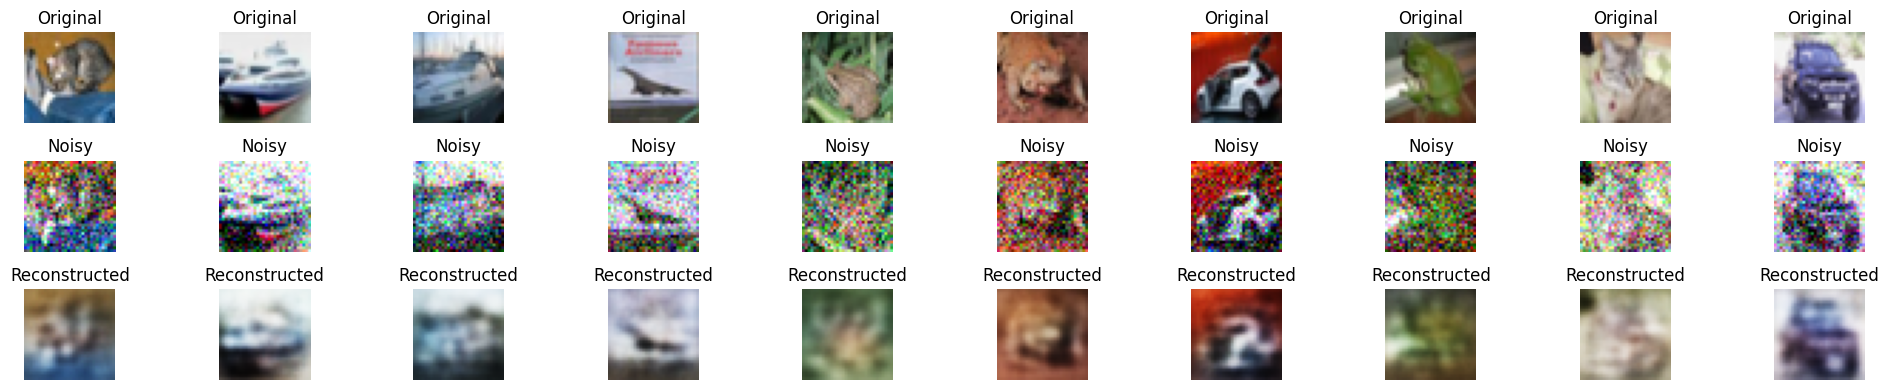

In [13]:
plot_reconstructed_images(autoencoder, x_test_noisy, x_test, n=10)

In [14]:
autoencoder_conv, encoder_conv, decoder_conv = build_convolutional_autoencoder()

In [15]:
history_conv_autoencoder = train_autoencoder(autoencoder_conv, x_train_noisy, x_train, x_test_noisy, x_test)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 87s 214ms/step - loss: 0.0178 - val_loss: 0.0135
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 71s 181ms/step - loss: 0.0088 - val_loss: 0.0087
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 69s 176ms/step - loss: 0.0076 - val_loss: 0.0082
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 187ms/step - loss: 0.0070 - val_loss: 0.0082
Epoch 5/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 211ms/step - loss: 0.0067 - val_loss: 0.0069
Epoch 6/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 78s 198ms/step - loss: 0.0065 - val_loss: 0.0065
Epoch 7/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 77s 196ms/step - loss: 0.0063 - val_loss: 0.0062
Epoch 8/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 84s 215ms/step - loss: 0.0061 - val_loss: 0.0066
Epoch 9/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 78s 200ms/step - loss: 0.0060 - val_loss: 0.0065
Epoch 10/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 80s 205ms/step - loss: 0.0059 - val_loss: 0.0061
Epoch 11/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 81s 208ms/step - loss: 0.0058 - val_loss: 0.0060
Epoch 12/50
391/391

In [16]:
test_loss_autoencoder = evaluate_autoencoder(autoencoder_conv, x_test_noisy, x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0052
Test loss (MSE): 0.0052011217921972275


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step


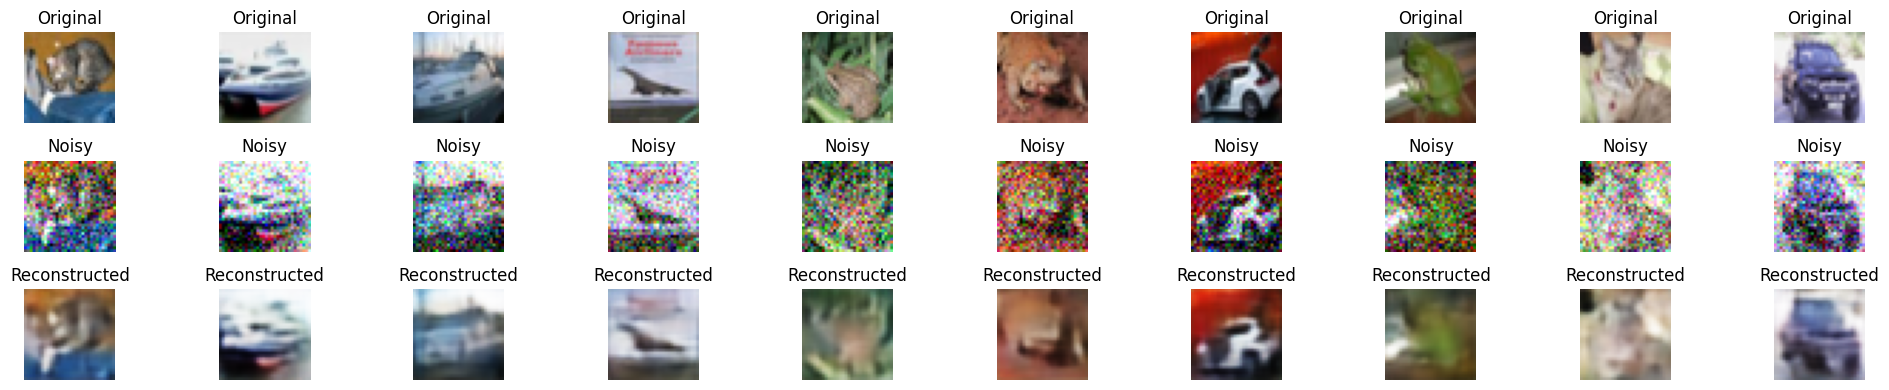

In [17]:
plot_reconstructed_images(autoencoder_conv, x_test_noisy, x_test, n=10)